In [1]:
!pip install wbgapi

In [2]:
import wbgapi as wb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define Economies: CHE (Switzerland), 	HIC (High Income), WLD (World)
country_codes = ['CHE', 'HIC', 'WLD']

indicators = {
    'NY.GDP.PCAP.KD': 'GDP_Per_Capita_Const',     # Standard of Living
    'SL.TLF.CACT.ZS': 'Labor_Part_Rate',          # Labor Supply
    'SL.UEM.TOTL.ZS': 'Unemployment_Rate',        # Labor Friction
    'SL.TLF.TOTL.IN': 'Labor_Force_Total',        # Total Workers
    'NY.GDP.MKTP.KD': 'GDP_Const',                # Economic Size
    'FP.CPI.TOTL.ZG': 'Inflation_CPI',            # Stability
    'NY.GDS.TOTL.ZS': 'Gross_Dom_Savings',        # Savings
    'NE.GDI.TOTL.ZS': 'Gross_Cap_Formation',      # Investment
    'NE.EXP.GNFS.ZS': 'Exports_GDP',              # Exports
    'NE.IMP.GNFS.ZS': 'Imports_GDP',              # Imports
    'GC.TAX.TOTL.GD.ZS': 'Tax_Rev_GDP',           # Gov Revenue
    'NE.CON.GOVT.ZS': 'Gov_Exp_GDP'               # Gov Spending
}

In [3]:
# 1. fetch Data
print("Fetching data...")
df_raw = wb.data.DataFrame(indicators, economy=country_codes, time=range(1970, 2025))

# 2. Transpose (Flip Rows/Cols)
df = df_raw.T

# 3. Clean Index
df.index = df.index.str.replace('YR', '').astype(int)
df.index.name = 'Year'
df = df.sort_index()

# 4. Rename Columns
df.rename(columns=indicators, level=1, inplace=True)

# 5. Extract CHE for specific calculations
df_che = df.xs('CHE', axis=1, level=0).copy()

Fetching data...


In [4]:
df

economy           CHE                                                          \
series  Inflation_CPI Tax_Rev_GDP Gov_Exp_GDP Exports_GDP Gross_Cap_Formation   
Year                                                                            
1970         3.615987         NaN    7.770036   41.314391           40.507290   
1971         6.573221         NaN    8.088365   39.245128           40.785069   
1972         6.660007    6.794367    8.068210   38.641079           39.914301   
1973         8.754670    6.468733    8.331328   38.993361           39.336752   
1974         9.767414    6.623875    8.622326   41.017705           39.236030   
1975         6.696595    6.696349    9.352055   39.607594           28.851507   
1976         1.715476    7.685615    9.757844   42.363395           26.038698   
1977         1.295999    7.380171    9.605716   46.218699           26.043746   
1978         1.028793    7.556425    9.533532   44.242539           27.260449   
1979         3.647640    7.126462    9.592579   44.544097           29.972282   
1980         4.022501    7.292198    9.435803   46.321518           34.150623   
1981         6.490310    7.307529    9.594401   48.245023           31.439355   
1982         5.655102    7.600636    9.836800   44.383567           31.084697   
1983         2.949794    7.635406   10.116588   43.100684           31.504701   
1984         2.931457    7.792769    9.915989   47.296393           29.063945   
1985         3.435399    7.672089   10.023527   47.768461           29.858468   
1986         0.750310    8.309256   10.163728   43.952376           31.906200   
1987         1.440322    7.966644   10.112751   41.202337           31.503875   
1988         1.872469    8.338602   10.301708   42.377569           32.549882   
1989         3.155270    7.824866   10.725963   44.814876           33.316824   
1990         5.403959    7.953722   10.874982   41.358198           34.919634   
1991         5.859597    7.760840   11.459473   39.816635           31.712984   
1992         4.037030    7.919358   11.828657   40.732220           28.964604   
1993         3.292622    7.339651   11.839927   40.814117           27.582051   
1994         0.852117    7.855746   11.856907   40.064598           28.318695   
1995         1.799828    7.915461   11.808194   40.019708           28.063696   
1996         0.811634    8.338045   11.895829   41.027788           27.608261   
1997         0.520225    8.323929   11.630082   46.494481           26.090192   
1998         0.017938    9.261957   11.334291   45.994683           27.413105   
1999         0.806444    8.918887   11.352001   46.781015           27.080272   
2000         1.558529   10.032345   11.159891   51.437723           27.234191   
2001         0.989020    8.970633   11.163767   50.202696           27.695137   
2002         0.642712    8.955704   11.542898   48.559641           26.214940   
2003         0.638273    8.977577   11.734894   47.720718           25.984418   
2004         0.802909    9.020394   11.514910   51.299985           24.548464   
2005         1.171954    9.126161   11.248252   53.854174           27.189219   
2006         1.059509    9.194038   10.742765   56.609185           27.918934   
2007         0.732351    9.065624   10.424410   61.552815           26.788815   
2008         2.426041    9.587142   10.570699   63.129319           27.412026   
2009        -0.480482    9.348528   11.384625   58.009669           28.341989   
2010         0.688239    9.364008   11.183612   64.837628           25.895559   
2011         0.231349    9.321952   11.275572   66.449924           28.492419   
2012        -0.692552    9.169075   11.314927   67.777373           26.660229   
2013        -0.217323    9.256214   11.412579   72.068214           25.154934   
2014        -0.013203    9.087340   11.481636   65.337270           25.553196   
2015        -1.143909    9.556179   11.537567   63.828956           25.074863   
2016        -0.434619    9.4046

In [5]:
# 1. Natural Rate of Unemployment (5-Year MA)
df_che['Natural_Rate_Unemp'] = df_che['Unemployment_Rate'].rolling(window=5).mean()

# 2. Productivity (Output per Worker)
df_che['Productivity'] = df_che['GDP_Const'] / df_che['Labor_Force_Total']

# 3. Net Capital Outflow (Exports - Imports)
df_che['NCO'] = df_che['Exports_GDP'] - df_che['Imports_GDP']

# 4. Budget Balance (Tax - Spending)
df_che['Budget_Balance'] = df_che['Tax_Rev_GDP'] - df_che['Gov_Exp_GDP']

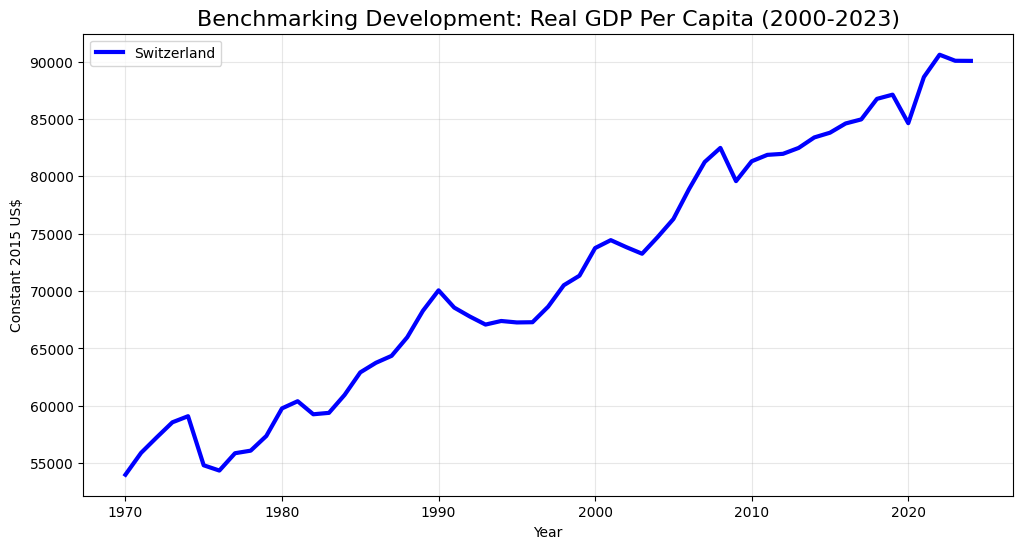

In [6]:
plt.figure(figsize=(12, 6))
# Plot ONLY SWitzerland
plt.plot(df.index, df[('CHE', 'GDP_Per_Capita_Const')], label='Switzerland', color='blue', linewidth=3)
plt.title('Benchmarking Development: Real GDP Per Capita (2000-2023)', fontsize=16)
plt.ylabel('Constant 2015 US$')
plt.xlabel('Year')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

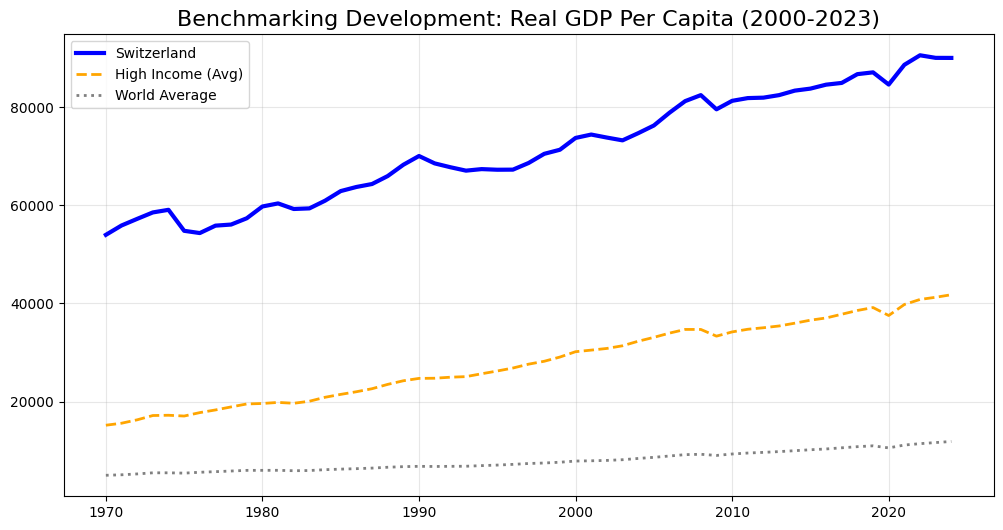

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df[('CHE', 'GDP_Per_Capita_Const')], label='Switzerland', color='blue', linewidth=3)
# ADD THESE LINES
plt.plot(df.index, df[('HIC', 'GDP_Per_Capita_Const')], label='High Income (Avg)', color='orange', linestyle='--', linewidth=2)
plt.plot(df.index, df[('WLD', 'GDP_Per_Capita_Const')], label='World Average', color='grey', linestyle=':', linewidth=2)

plt.title('Benchmarking Development: Real GDP Per Capita (2000-2023)', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

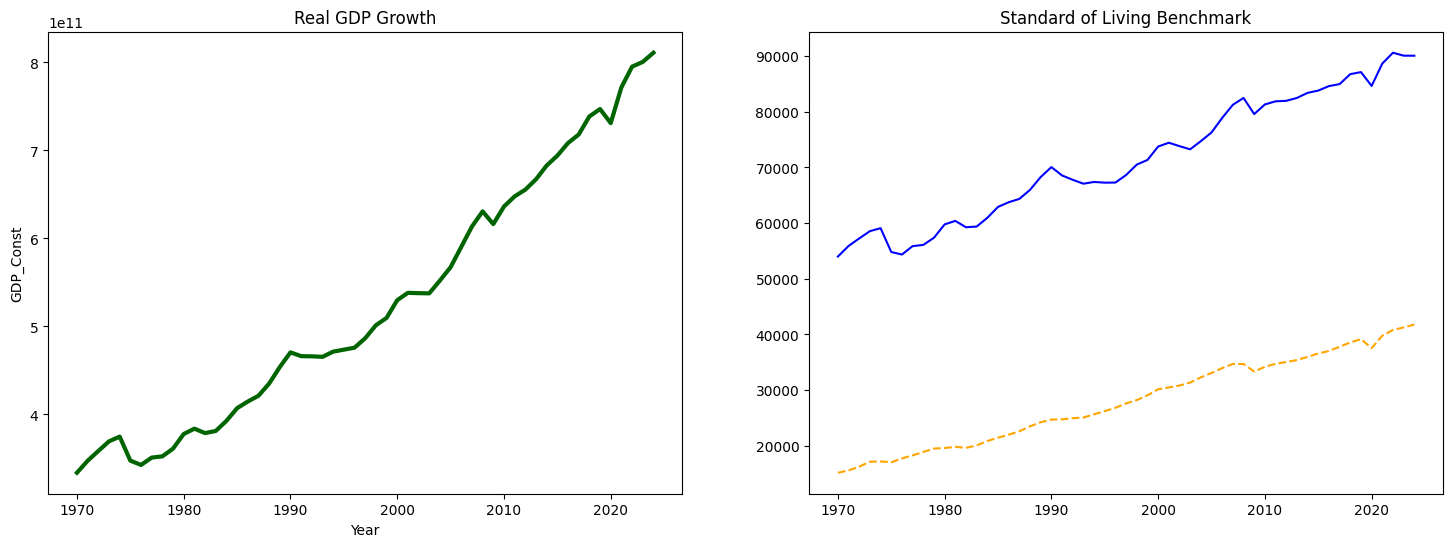

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Chart A: Total GDP
sns.lineplot(data=df_che, x=df_che.index, y='GDP_Const', color='darkgreen', linewidth=3, ax=ax1)
ax1.set_title('Real GDP Growth')

# Chart B: GDP Per Capita Benchmark
ax2.plot(df.index, df[('CHE', 'GDP_Per_Capita_Const')], color='blue')
ax2.plot(df.index, df[('HIC', 'GDP_Per_Capita_Const')], color='orange', linestyle='--')
ax2.set_title('Standard of Living Benchmark')
plt.show()

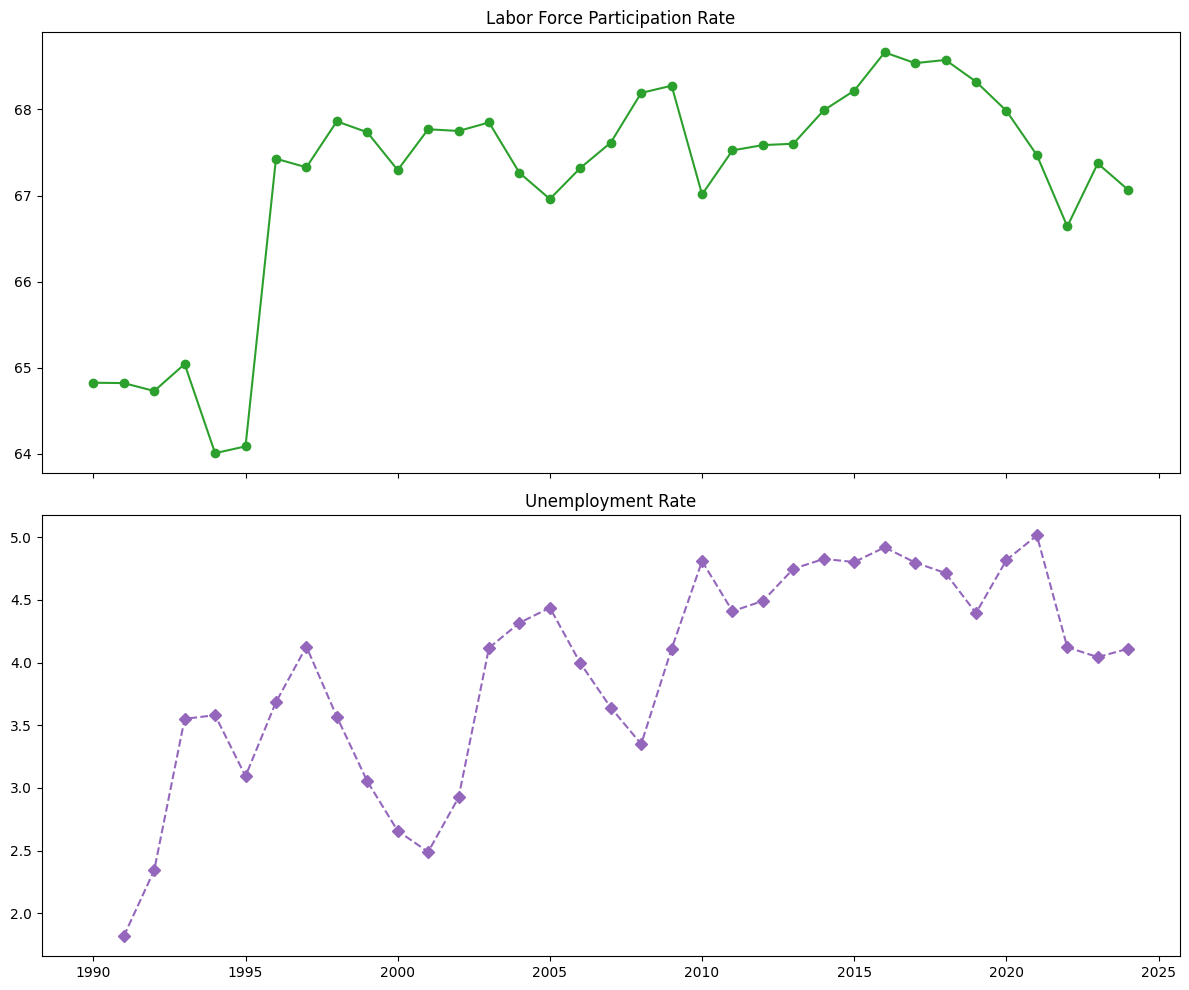

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Top: Participation
ax1.plot(df_che.index, df_che['Labor_Part_Rate'], color='tab:green', marker='o')
ax1.set_title('Labor Force Participation Rate')

# Bottom: Unemployment
ax2.plot(df_che.index, df_che['Unemployment_Rate'], color='tab:purple', marker='D', linestyle='--')
ax2.set_title('Unemployment Rate')
plt.tight_layout()
plt.show()

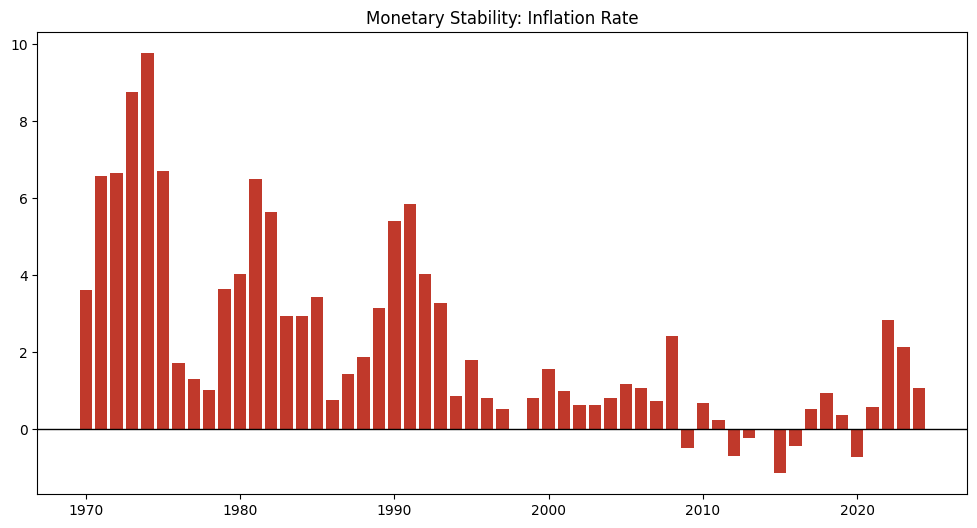

In [10]:
plt.figure(figsize=(12, 6))

plt.bar(df_che.index, df_che['Inflation_CPI'], color='#c0392b')

plt.axhline(0, color='black', linewidth=1)
plt.title('Monetary Stability: Inflation Rate')
plt.show()

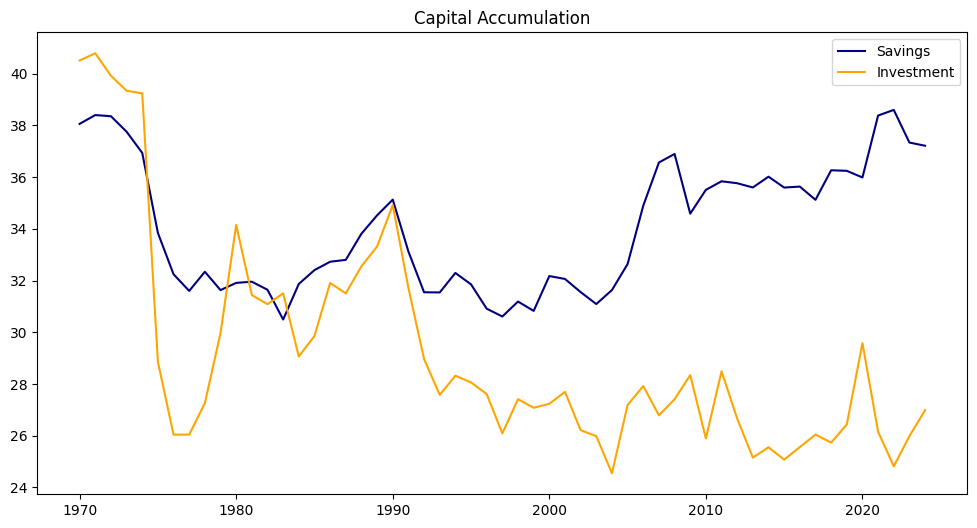

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(df_che.index, df_che['Gross_Dom_Savings'], label='Savings', color='navy')
plt.plot(df_che.index, df_che['Gross_Cap_Formation'], label='Investment', color='orange')
plt.title('Capital Accumulation')
plt.legend()
plt.show()

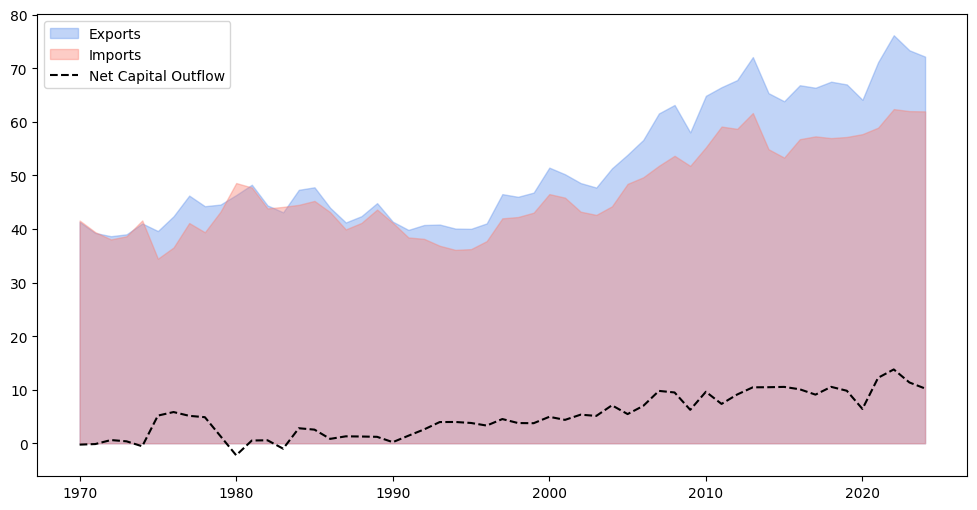

In [12]:
plt.figure(figsize=(12, 6))
plt.fill_between(df_che.index, df_che['Exports_GDP'], color='cornflowerblue', alpha=0.4, label='Exports')
plt.fill_between(df_che.index, df_che['Imports_GDP'], color='salmon', alpha=0.4, label='Imports')
plt.plot(df_che.index, df_che['NCO'], color='black', linestyle='--', label='Net Capital Outflow')
plt.legend()
plt.show()

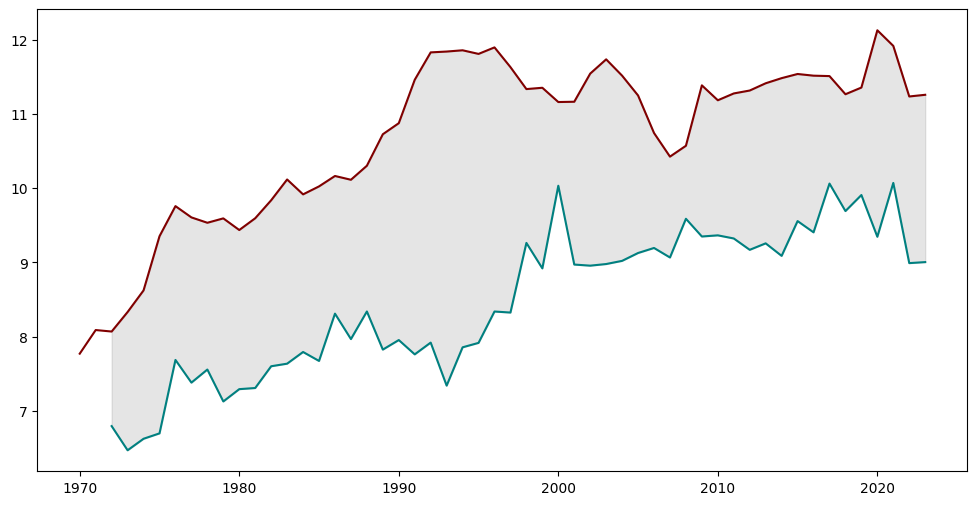

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(df_che.index, df_che['Tax_Rev_GDP'], label='Revenue', color='teal')
plt.plot(df_che.index, df_che['Gov_Exp_GDP'], label='Expenditure', color='maroon')
plt.fill_between(df_che.index, df_che['Tax_Rev_GDP'], df_che['Gov_Exp_GDP'], color='gray', alpha=0.2)
plt.show()

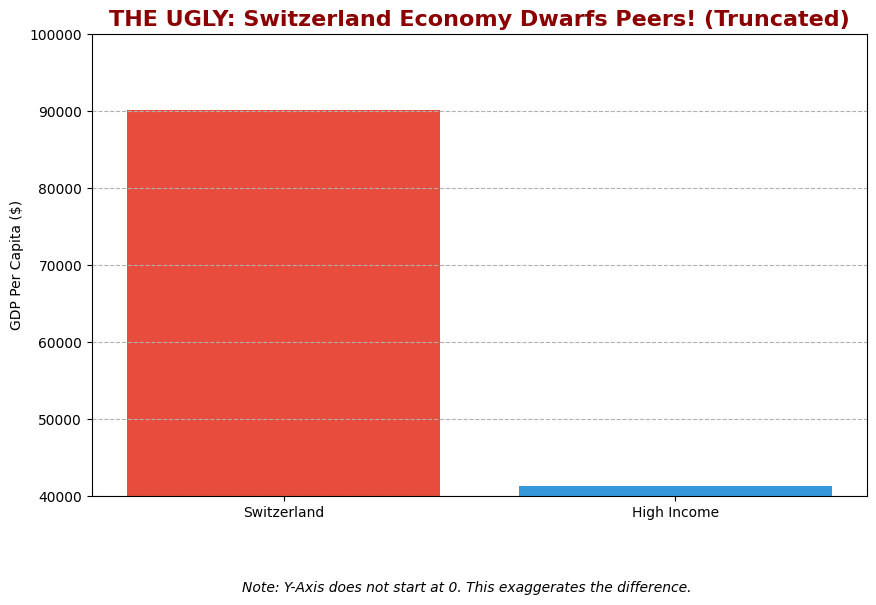

In [14]:
# THE UGLY CHART
# Setup snapshot data for the latest available year
snapshot_year = 2023
che_val = df.loc[snapshot_year, ('CHE', 'GDP_Per_Capita_Const')]
hic_val = df.loc[snapshot_year, ('HIC', 'GDP_Per_Capita_Const')]

values = [che_val, hic_val]
labels = ['Switzerland', 'High Income']

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['#e74c3c', '#3498db'])

# THE VIOLATION: Truncating the axis
# Switzerland is approx 90000. High Income is approx 40000.
# Starting axis at 4000 makes High Income look tiny.
plt.ylim(40000, 100000)

plt.title('THE UGLY: Switzerland Economy Dwarfs Peers! (Truncated)', fontsize=16, fontweight='bold', color='darkred')
plt.ylabel('GDP Per Capita ($)')
plt.grid(axis='y', linestyle='--')
plt.figtext(0.5, -0.05, "Note: Y-Axis does not start at 0. This exaggerates the difference.", ha="center", style='italic')

plt.show()

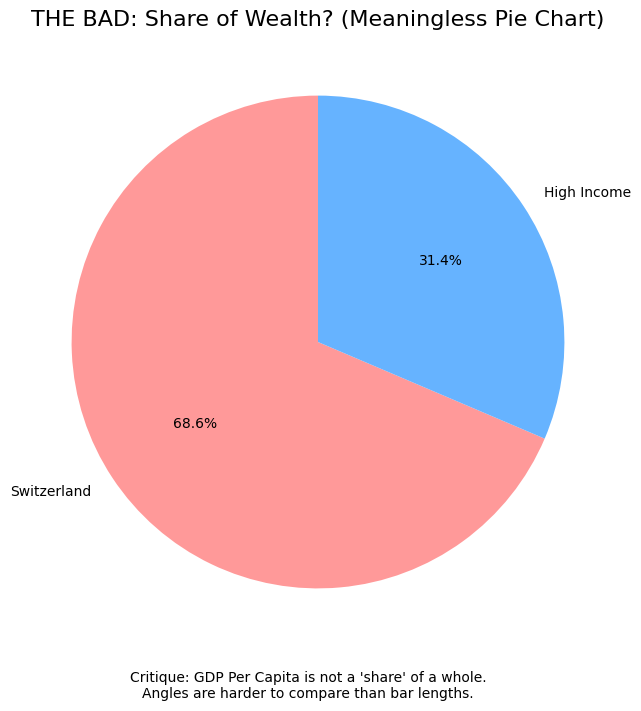

In [15]:
# CELL 9: THE BAD CHART
plt.figure(figsize=(8, 8))

# THE VIOLATION: Using a Pie Chart for non-summable data (GDP Per Capita)
# Comparison of magnitudes should be a Bar Chart, not angles.
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)

plt.title('THE BAD: Share of Wealth? (Meaningless Pie Chart)', fontsize=16)
plt.figtext(0.5, 0.05, "Critique: GDP Per Capita is not a 'share' of a whole.\nAngles are harder to compare than bar lengths.", ha="center")

plt.show()

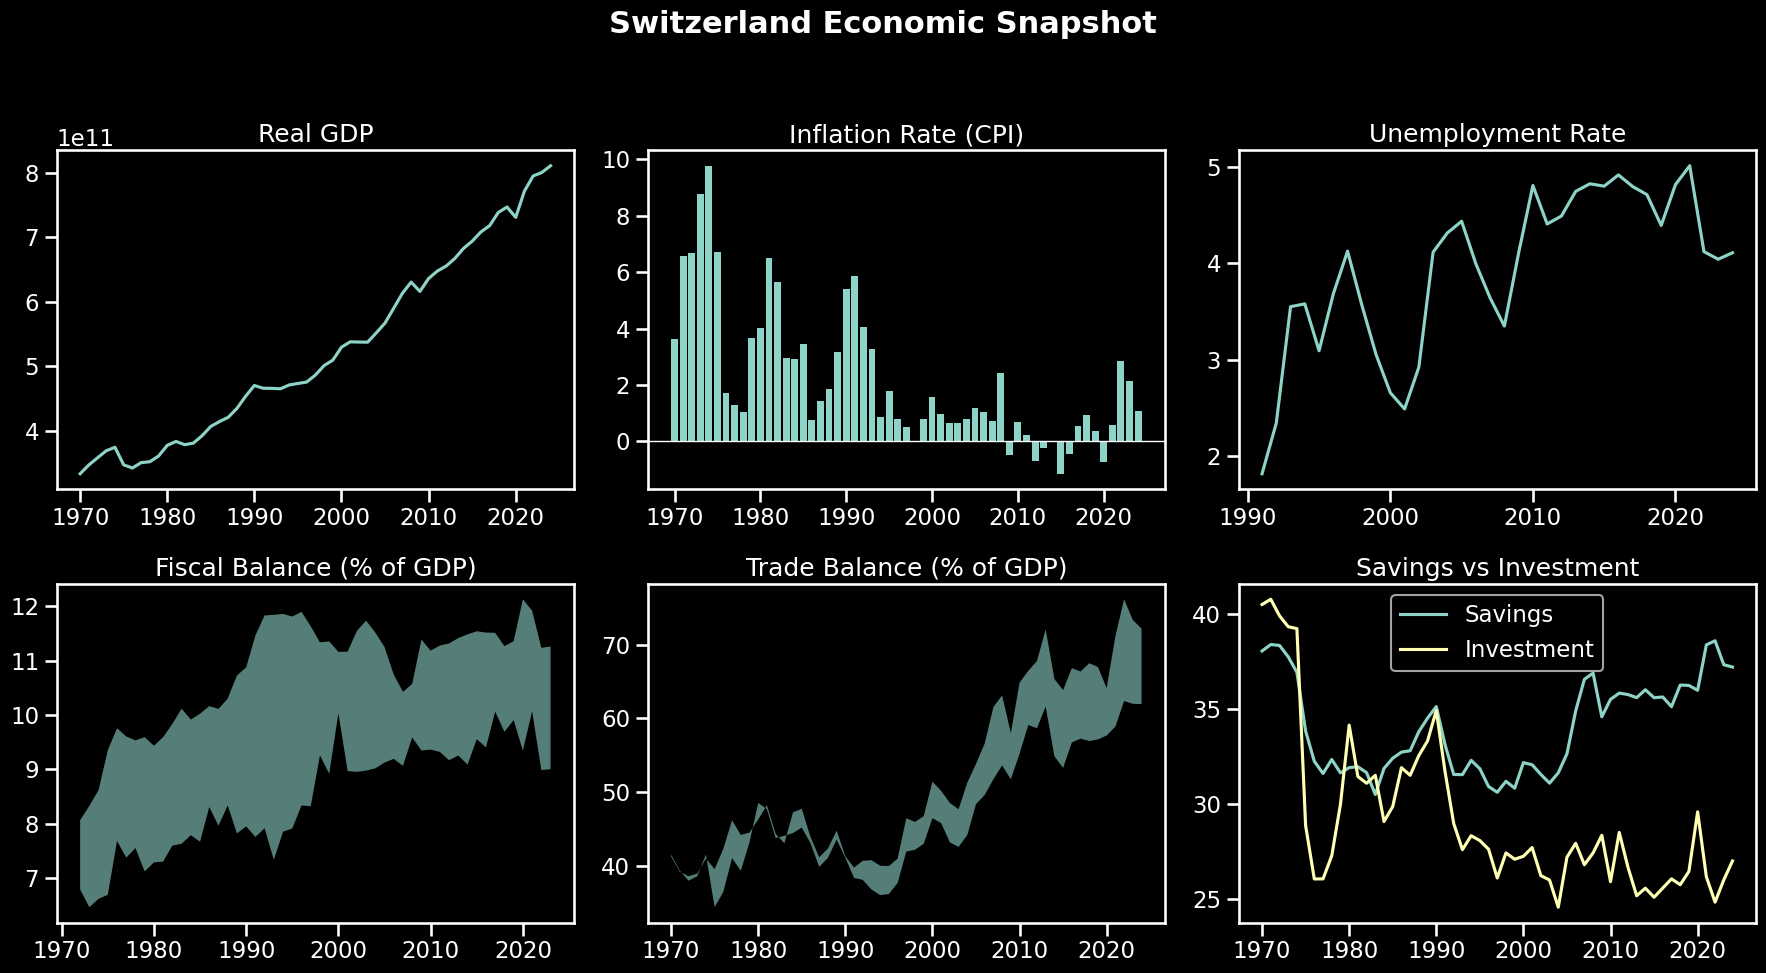

In [19]:
plt.style.use('dark_background')
sns.set_context("talk")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Switzerland Economic Snapshot", fontsize=22, fontweight="bold")

# Real GDP
axes[0, 0].plot(df_che.index, df_che['GDP_Const'])
axes[0, 0].set_title("Real GDP")

# Inflation
axes[0, 1].bar(df_che.index, df_che['Inflation_CPI'])
axes[0, 1].axhline(0, linewidth=1)
axes[0, 1].set_title("Inflation Rate (CPI)")

# Unemployment
axes[0, 2].plot(df_che.index, df_che['Unemployment_Rate'])
axes[0, 2].set_title("Unemployment Rate")

# Fiscal balance
axes[1, 0].fill_between(
    df_che.index,
    df_che['Tax_Rev_GDP'],
    df_che['Gov_Exp_GDP'],
    alpha=0.6
)
axes[1, 0].set_title("Fiscal Balance (% of GDP)")

# Trade balance
axes[1, 1].fill_between(
    df_che.index,
    df_che['Exports_GDP'],
    df_che['Imports_GDP'],
    alpha=0.6
)
axes[1, 1].set_title("Trade Balance (% of GDP)")

# Savings vs investment
axes[1, 2].plot(df_che.index, df_che['Gross_Dom_Savings'], label="Savings")
axes[1, 2].plot(df_che.index, df_che['Gross_Cap_Formation'], label="Investment")
axes[1, 2].set_title("Savings vs Investment")
axes[1, 2].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()